# Fake, Real and AI-Generated News Detection
### [CM3070] Final Project, NLP Fake News Detection Template

## 1. Project Setup
Let's start with importing the necessary libraries and the three datasets to be used in this project, the 'Fake and Real News' Kaggle dataset, the LIAR dataset and the GPT2-output dataset.

### 1.1 Importing Libraries and Tools

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt #Plotting properties
import seaborn as sns
# Set style for seaborn for better readability
sns.set(style="whitegrid")
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For WordNet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Show all matplotlib graphs inline
%matplotlib inline

[nltk_data] Downloading package stopwords to /Users/yassu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/yassu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/yassu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### 1.2 Import GPT2-output Dataset

In [6]:
import os
import sys
import requests
from tqdm import tqdm
import re

In [7]:
# subdir = 'data'
# if not os.path.exists(subdir):
#     os.makedirs(subdir)
# subdir = subdir.replace('\\','/') # needed for Windows


# # Just downloading outputs from strongest version (xl-1542M)

# # The dataset contains train, valid and test sets, but the number of samples
# # is so large that we only need the training set (250,000 samples)
# filename = 'xl-1542M-k40.train.jsonl'
# r = requests.get("https://openaipublic.azureedge.net/gpt-2/output-dataset/v1/" + filename, stream=True)

# with open(os.path.join(subdir, filename), 'wb') as f:
#     file_size = int(r.headers["content-length"])
#     chunk_size = 1000
#     with tqdm(ncols=100, desc="Fetching " + filename, total=file_size, unit_scale=True) as pbar:
#         # 1k for chunk_size, since Ethernet packet size is around 1500 bytes
#         for chunk in r.iter_content(chunk_size=chunk_size):
#             f.write(chunk)
#             pbar.update(chunk_size)

In [8]:
# ai_df = pd.read_json('data/xl-1542M-k40.train.jsonl', lines=True)

In [9]:
# ai_df.to_csv('data/gpt2_output.csv', index=False)

In [10]:
gpt2_df = pd.read_csv('data/gpt2_output.csv')

In [11]:
# Confirm length is correct (250,000 expected)
print("Number of AI text articles: " + str(len(gpt2_df)))

Number of AI text articles: 250000


In [12]:
gpt2_df.head()

,id,text,length,ended
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True
1,2,The latest edition of the German Football Hall...,715,True
2,3,"Dangerous animals, especially snakes, in a car...",1024,False
3,4,I started my first MLP story way back in 2014 ...,1024,False
4,5,This article is a disambiguation page for The ...,84,True


In [13]:
# Printing first output
gpt2_df.iloc[0, 1]

'Cops will have to take "extreme care" to avoid jail-breaking the latest iPhones as the US government will fine manufacturers for breaking its digital security.\n\nApple has been criticised for designing and releasing its latest smartphone without any security measures.\n\nApple has defended the iPhone 6 for carrying out some of its advanced security measures, but will be fined if it continues to fail that test.\n\nThe Federal Communications Commission and FBI will be allowed to fine companies as much as $25,000 (£17,800) for not patching bugs after they are announced.\n\nThe FCC, under a new ruling from president Obama , will allow fines of $1,500 per device over the same "bug bounty".\n\nThere have been multiple hacks into iPhone 6 smartphones this year in the wake of the 2013 revelation that the device could be unlocked with a passcode lock.\n\nHowever, security experts have criticised Apple\'s software and device for not patching its bugs to prevent them becoming the latest weapon 

### 1.3 Import the 'Fake and Real News' Kaggle Dataset

In [15]:
# Load Kaggle Dataset (Real vs. Fake News)
real_news = pd.read_csv('data/True.csv')
fake_news = pd.read_csv('data/Fake.csv')

In [16]:
real_news.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [17]:
fake_news.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


### 1.4 Import the LIAR Dataset

In [19]:
# Load LIAR dataset
# Import the LIAR dataset without headers
columns = ["id", "label", "statement", "subject", "speaker", "job_title", "state", 
           "party", "barely_true_count", "false_count", "half_true_count", 
           "mostly_true_count", "pants_fire_count", "context"]

liar_train = pd.read_csv("data/train.tsv", sep='\t', header=None, names=columns)  # LIAR is tab-separated
liar_test = pd.read_csv("data/test.tsv", sep='\t', header=None, names=columns)
liar_valid = pd.read_csv("data/valid.tsv", sep='\t', header=None, names=columns)

In [20]:
liar_train.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [21]:
liar_test.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [22]:
liar_valid.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,12134.json,barely-true,We have less Americans working now than in the...,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
2,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
3,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
4,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News


## 2. Data Pre-processing and Cleaning
After all the datasets have been imported, we will go into pre-processing and cleaning them.

### 2.1 Pre-processing the 'Fake and Real News' Kaggle Dataset

In [25]:
# combining true and fake dataframes and adding a column for labels
fake_news['label'] = 'fake'
real_news['label'] = 'real'
news_df = pd.concat([fake_news, real_news], ignore_index=True)

In [26]:
news_df = news_df.drop_duplicates(subset='text').reset_index(drop=True)

In [27]:
news_df = news_df.dropna(subset=['text'])

In [28]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove special characters and numbers, keep only letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text into words
    words = text.split()
    # Remove stopwords and lemmatize each word
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Rejoin the words into a single string
    return " ".join(words)

In [29]:
news_df['cleaned_text'] = news_df['text'].apply(clean_text)

In [30]:
news_df.head()

,title,text,subject,date,label,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake,pope francis used annual christmas day message...


In [31]:
news_df.tail()

,title,text,subject,date,label,cleaned_text
38641,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",real,brussels reuters nato ally tuesday welcomed pr...
38642,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",real,london reuters lexisnexis provider legal regul...
38643,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",real,minsk reuters shadow disused sovietera factory...
38644,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",real,moscow reuters vatican secretary state cardina...
38645,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",real,jakarta reuters indonesia buy sukhoi fighter j...


In [32]:
news_df.drop(['date', 'text', 'subject'], axis=1, inplace=True)

In [33]:
news_df.head()

,title,label,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,fake,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,fake,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,fake,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,fake,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,fake,pope francis used annual christmas day message...


In [34]:
news_df = news_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [35]:
news_df.drop(['title'], axis=1, inplace=True)

In [36]:
news_df = news_df[["text", "label"]]

In [37]:
news_df.head()

,text,label
0,donald trump wish american happy new year leav...,fake
1,house intelligence committee chairman devin nu...,fake
2,friday revealed former milwaukee sheriff david...,fake
3,christmas day donald trump announced would bac...,fake
4,pope francis used annual christmas day message...,fake


### 2.2 Pre-processing the LIAR Dataset

In [39]:
# Drop unnecessary columns
columns_to_keep = ["label", "statement"]
liar_train = liar_train[columns_to_keep]
liar_test = liar_test[columns_to_keep]
liar_valid = liar_valid[columns_to_keep]

In [40]:
liar_valid.head()

,label,statement
0,barely-true,We have less Americans working now than in the...
1,pants-fire,"When Obama was sworn into office, he DID NOT u..."
2,false,Says Having organizations parading as being so...
3,half-true,Says nearly half of Oregons children are poor.
4,half-true,On attacks by Republicans that various program...


In [41]:
liar_test.head()

,label,statement
0,true,Building a wall on the U.S.-Mexico border will...
1,false,Wisconsin is on pace to double the number of l...
2,false,Says John McCain has done nothing to help the ...
3,half-true,Suzanne Bonamici supports a plan that will cut...
4,pants-fire,When asked by a reporter whether hes at the ce...


In [42]:
liar_train.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [43]:
liar_df = pd.concat([liar_train, liar_test, liar_valid], ignore_index=True)

In [44]:
liar_df.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [45]:
liar_df.tail()

,label,statement
12786,half-true,"For the first time in more than a decade, impo..."
12787,mostly-true,Says Donald Trump has bankrupted his companies...
12788,true,"John McCain and George Bush have ""absolutely n..."
12789,false,A new poll shows 62 percent support the presid...
12790,barely-true,No one claims the report vindicating New Jerse...


In [46]:
# Shuffle the data to ensure randomness
liar_df = liar_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [47]:
def simplify_label(label):
    if label in ['false', 'pants-fire', 'barely-true']:
        return 'fake'
    else:
        return 'real'

liar_df['label'] = liar_df['label'].apply(simplify_label)

In [48]:
liar_df.head()

,label,statement
0,fake,"In the event of a U.S. strike on Syria, the Ru..."
1,real,To give the proposed economic stimulus plan so...
2,fake,Its warmer on Mars than it is in parts of the ...
3,real,The health insurance plan that (members of Con...
4,fake,He's promising four more years of an administr...


In [49]:
liar_df.describe()

,label,statement
count,12791,12791
unique,2,12765
top,real,On changing the rules for filibusters on presi...
freq,7134,3


In [50]:
liar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12791 entries, 0 to 12790
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      12791 non-null  object
 1   statement  12791 non-null  object
dtypes: object(2)
memory usage: 200.0+ KB


In [51]:
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

In [52]:
liar_df = liar_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [53]:
liar_df.drop(['statement'], axis=1, inplace=True)

In [54]:
liar_df = liar_df[["text", "label"]]

In [55]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give proposed economic stimulus plan perspecti...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


### 2.3 Pre-processing the GPT2-output Dataset

In [57]:
gpt2_df["label"] = "AI-generated"

In [58]:
gpt2_df.head()

,id,text,length,ended,label
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True,AI-generated
1,2,The latest edition of the German Football Hall...,715,True,AI-generated
2,3,"Dangerous animals, especially snakes, in a car...",1024,False,AI-generated
3,4,I started my first MLP story way back in 2014 ...,1024,False,AI-generated
4,5,This article is a disambiguation page for The ...,84,True,AI-generated


In [59]:
gpt2_df.drop(['id', 'length', 'ended'], axis=1, inplace=True)

In [60]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [61]:
# Remove duplicates and handle missing values
gpt2_df.drop_duplicates(subset="text", inplace=True)
gpt2_df.dropna(subset=["text"], inplace=True)

In [62]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [63]:
gpt2_df['text'] = gpt2_df['text'].apply(clean_text)

In [64]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking lates...,AI-generated
1,latest edition german football hall fame ballo...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,started first mlp story way back joke well rea...,AI-generated
4,article disambiguation page big apple followin...,AI-generated


### 2.4 Checking All the Datasets

In [66]:
news_df.head()

,text,label
0,donald trump wish american happy new year leav...,fake
1,house intelligence committee chairman devin nu...,fake
2,friday revealed former milwaukee sheriff david...,fake
3,christmas day donald trump announced would bac...,fake
4,pope francis used annual christmas day message...,fake


In [67]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give proposed economic stimulus plan perspecti...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


In [68]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking lates...,AI-generated
1,latest edition german football hall fame ballo...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,started first mlp story way back joke well rea...,AI-generated
4,article disambiguation page big apple followin...,AI-generated


In [69]:
news_df.tail()

,text,label
38641,brussels reuters nato ally tuesday welcomed pr...,real
38642,london reuters lexisnexis provider legal regul...,real
38643,minsk reuters shadow disused sovietera factory...,real
38644,moscow reuters vatican secretary state cardina...,real
38645,jakarta reuters indonesia buy sukhoi fighter j...,real


In [70]:
liar_df.tail()

,text,label
12786,say opponent health care law prevailed two mai...,real
12787,mosque near ground zero,real
12788,louie gohmert texas blamed mass shooting movie...,fake
12789,governor consult member party released transpo...,fake
12790,telecom bill could keep state corporation comm...,fake


In [71]:
gpt2_df.tail()

,text,label
249995,lot thing dont like job cooped office long hou...,AI-generated
249996,year unprecedented public outcry use water pun...,AI-generated
249997,battle english scot english victory flodden ki...,AI-generated
249998,kurt rambis new head coach knicks kurt rambis ...,AI-generated
249999,leader need thats differ new president united ...,AI-generated


In [72]:
# saving all cleaned dataframes to CSV files.
news_df.to_csv('data/news.csv', index=False)
liar_df.to_csv('data/liar.csv', index=False)
gpt2_df.to_csv('data/gpt2.csv', index=False)

In [73]:
news_df["label"].value_counts()

label
real    21191
fake    17455
Name: count, dtype: int64

In [74]:
liar_df["label"].value_counts()

label
real    7134
fake    5657
Name: count, dtype: int64

In [75]:
gpt2_df["label"].value_counts()

label
AI-generated    249796
Name: count, dtype: int64

### 2.4 Downsampling the GPT-2-output Dataset
The GPT-2 output dataset is about 250000 values which need to be downsamlped to avoid data imbalance and model bias.

In [77]:
gpt2_sampled = gpt2_df.sample(n=23000, random_state=42)

### 2.5 Downsampling the 'real' samples in LIAR and Kaggle Datasets
This reduces bias from the overrepresented real class while preserving the diversity of text samples, because real has significantly more samples than fake in news_df and liar_df.

In [79]:
# Downsample real class in news_df
real_downsampled = news_df[news_df['label'] == 'real'].sample(n=17455, random_state=42)
fake = news_df[news_df['label'] == 'fake']
balanced_news_df = pd.concat([real_downsampled, fake])

# Downsample real class in news_df
liar_real_downsampled = liar_df[liar_df['label'] == 'real'].sample(n=5657, random_state=42)
liar_fake = liar_df[liar_df['label'] == 'fake']
balanced_liar_df = pd.concat([liar_real_downsampled, liar_fake])

### 2.6 Merging the Datasets
After balancing, I will combine gpt2_df, balanced_news_df, and balanced_liar_df.

In [81]:
# Rename labels for consistency
gpt2_sampled['label'] = 'AI-generated'
balanced_news_df['label'] = balanced_news_df['label'].map({'real': 'real', 'fake': 'fake'})
balanced_liar_df['label'] = balanced_liar_df['label'].map({'real': 'real', 'fake': 'fake'})

# Merge datasets
merged_df = pd.concat([balanced_news_df, balanced_liar_df, gpt2_sampled])

In [82]:
merged_df['label'].value_counts()

label
real            23112
fake            23112
AI-generated    23000
Name: count, dtype: int64

### 2.7 Shuffling the dataset to mix samples from different sources.

In [84]:
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [85]:
merged_df['label'].value_counts()

label
real            23112
fake            23112
AI-generated    23000
Name: count, dtype: int64

In [86]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69224 entries, 0 to 69223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69224 non-null  object
 1   label   69224 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [87]:
merged_df.shape

(69224, 2)

In [88]:
merged_df.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

In [90]:
# Get basic info (data types, non-null counts)
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69224 entries, 0 to 69223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69224 non-null  object
 1   label   69224 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB
None


In [91]:
# Get statistical summary for numerical columns
print(merged_df.describe())

         text  label
count   69224  69224
unique  69035      3
top             real
freq       63  23112


In [92]:
# Check for null values
print(merged_df.isnull().sum())

text     0
label    0
dtype: int64


/var/folders/w5/1ych38yj6yj23h6z6t94wlz40000gn/T/ipykernel_1934/2695789455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='label', palette='muted')


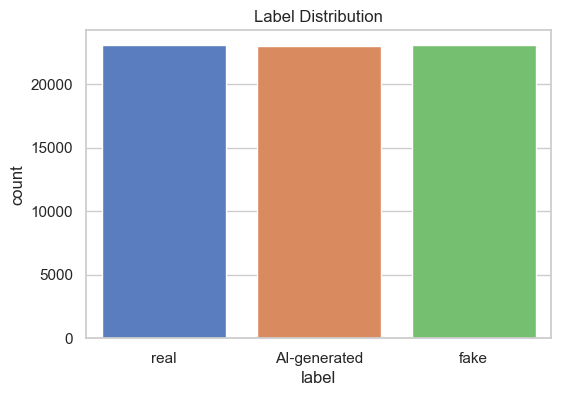

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=merged_df, x='label', palette='muted')
plt.title('Label Distribution')
plt.show()

/var/folders/w5/1ych38yj6yj23h6z6t94wlz40000gn/T/ipykernel_1934/2752930403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='label', y=merged_df['text'].apply(len), palette='muted')


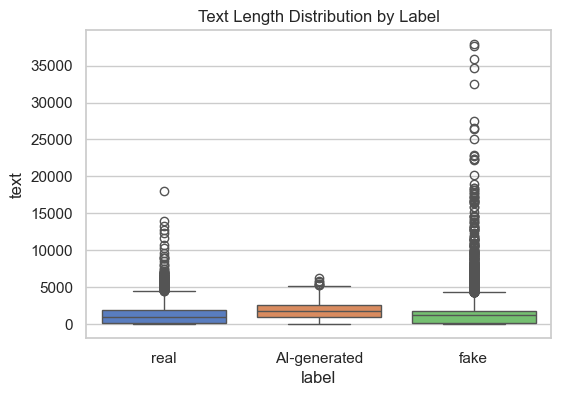

In [94]:
# Plot text length vs label
plt.figure(figsize=(6, 4))
sns.boxplot(data=merged_df, x='label', y=merged_df['text'].apply(len), palette='muted')
plt.title('Text Length Distribution by Label')
plt.show()

In [95]:
# Check for duplicates in text and label columns
duplicates = merged_df.duplicated(subset=['text', 'label'])
print(f"Number of duplicate entries: {duplicates.sum()}")

Number of duplicate entries: 184


In [96]:
merged_df = merged_df.drop_duplicates(subset=['text', 'label'], keep='first')

In [97]:
merged_df['label'].value_counts()

label
fake            23031
real            23024
AI-generated    22985
Name: count, dtype: int64

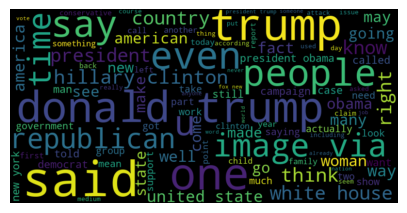

In [98]:
from wordcloud import WordCloud

wordcloud_text = ''.join(merged_df[merged_df['label']=='fake']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

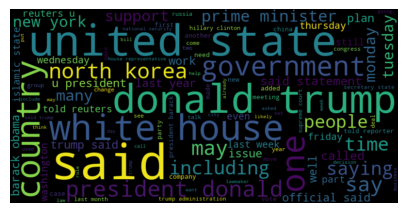

In [99]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='real']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

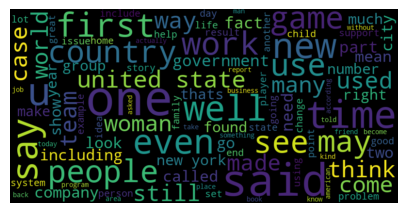

In [100]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='AI-generated']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 4. Baseline Modeling
### 4.1 Data Splitting
Spliting the dataset into training, validation, and testing sets:
- Training Set: 64% of the data
- Validation Set: 16% of the data
- Testing Set: 20% of the data

In [102]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training and 20% testing.
train_df, test_df = train_test_split(merged_df, test_size=0.2, stratify=merged_df['label'], random_state=42)
# Then taking 20% of the 80% training data (16% of the original dataset) for validation.
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)

### 4.2 Vectorization with TF-IDF

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [105]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=10_000)
X_train = vectorizer.fit_transform(train_df['text'])
X_val = vectorizer.transform(val_df['text'])
X_test = vectorizer.transform(test_df['text'])

If the labels are text strings ("fake", "real", "AI-generated"), they need to be encoded numerically for sklearn models. LabelEncoder or OneHotEncoder can be used.

In [107]:
# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

### 4.3 Training the Logistic Regression Model

In [109]:
# Model Training
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [110]:
# Validation Predictions
y_pred = model.predict(X_val)

## 5. Model Evaluation

In [112]:
# Print Accuracy Score
print(accuracy_score(y_val, y_pred))

0.8697383905132615


In [113]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

Validation Metrics:
              precision    recall  f1-score   support

AI-generated       0.92      0.91      0.92      3678
        fake       0.84      0.84      0.84      3685
        real       0.85      0.86      0.86      3684

    accuracy                           0.87     11047
   macro avg       0.87      0.87      0.87     11047
weighted avg       0.87      0.87      0.87     11047



In [114]:
# Test Predictions
y_test_pred = model.predict(X_test)
print("Test Metrics:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Test Metrics:
              precision    recall  f1-score   support

AI-generated       0.92      0.91      0.92      4597
        fake       0.85      0.85      0.85      4606
        real       0.86      0.87      0.86      4605

    accuracy                           0.88     13808
   macro avg       0.88      0.88      0.88     13808
weighted avg       0.88      0.88      0.88     13808



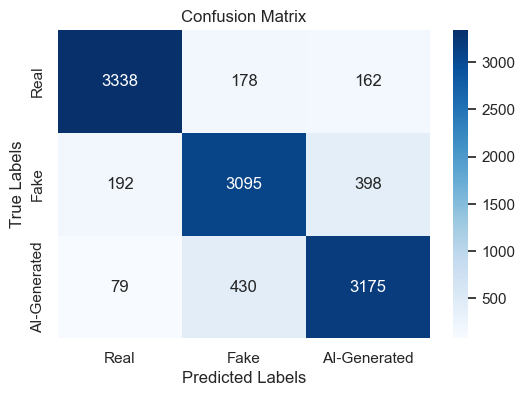

In [115]:
from sklearn.metrics import confusion_matrix

# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Investigating Different Methodologies
### 6. Word2Vec with Random Forest Classifier

In [117]:
# print percentage of each label
print(merged_df['label'].value_counts(normalize=True) * 100)

label
fake            33.358922
real            33.348783
AI-generated    33.292294
Name: proportion, dtype: float64


In [118]:
# Retokenizing the text into lists of words
merged_df['tokenized_text'] = merged_df['text'].apply(lambda x: x.split())

In [119]:
merged_df.head(5)

,text,label,tokenized_text
0,berlin reuters turkey summoned germany ambassa...,real,"[berlin, reuters, turkey, summoned, germany, a..."
1,florida woman charged killing husband shot wou...,AI-generated,"[florida, woman, charged, killing, husband, sh..."
2,final day afghanistan president obama haunted ...,AI-generated,"[final, day, afghanistan, president, obama, ha..."
3,group grifter clinton scammer chelsea demand h...,fake,"[group, grifter, clinton, scammer, chelsea, de..."
4,republican front runner donald trump recently ...,fake,"[republican, front, runner, donald, trump, rec..."


In [120]:
# Extract tokenized sentences as a list of lists
tokenized_data = merged_df['tokenized_text'].tolist()

In [121]:
from gensim.models import Word2Vec

# Train Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=3, workers=4)

# Save the model for later use
word2vec_model.save("word2vec.model")

In [122]:
# Example: Access the vector for a specific word
example_vector = word2vec_model.wv["president"]

In [123]:
print(example_vector)

[ 1.0023644  -3.88455    -0.6472256  -0.94010323  0.2548116  -0.619768
 -0.60371464  0.81939876  2.016096   -1.149662    0.7449257   1.0545388
  0.390972    0.16132957  2.7147388   1.669929    1.5250832   1.3100721
 -2.0867746   0.73054075 -2.1061578  -1.5895053   0.6342288  -3.1449034
 -2.3111494   2.2268112  -2.3225074  -2.7792342   1.8489015   0.3410476
 -1.5736903   0.26945925 -0.37421632  0.6042876   2.2310684  -0.5809909
  1.5833853   1.5160913   0.08147886  1.9863757   1.9068495   0.41840476
 -1.5509272   0.31182826 -1.4249072  -2.0796475   0.29753867  0.1250751
 -2.6020353  -0.29713148 -0.97010404 -3.1935675  -0.8313926  -1.8334509
  1.3616583   0.31056777 -0.25264373 -2.3112144   2.9318774   1.6988537
 -2.0335722  -1.0529742   0.47477764 -2.2960942  -2.2223518   0.85413176
 -1.3636051   0.38513708 -0.04001024  0.61332136  2.242428    2.1441138
 -0.75902593  2.4148316   1.6109166   0.57362974  0.7792253   0.8095976
 -2.5399275   0.98282564  0.7515985   3.3116155   0.83881605 -0

In [124]:
merged_df.to_csv("processed_data.csv", index=False)

In [125]:
print(len(word2vec_model.wv.key_to_index))  # Number of words in the vocabulary

76462


In [126]:
print(word2vec_model.wv.most_similar("president"))  # Check related words

[('presidentelect', 0.7207657694816589), ('presidentbiden', 0.6727503538131714), ('presidency', 0.6567102670669556), ('versa', 0.5540117621421814), ('presidential', 0.5466877222061157), ('administration', 0.5342409014701843), ('presidentthe', 0.5286439657211304), ('barack', 0.5223784446716309), ('successor', 0.5069172382354736), ('rumsfeld', 0.49610260128974915)]


In [127]:
print(word2vec_model.wv.most_similar("real", topn=5))

[('actual', 0.5858845710754395), ('obvious', 0.5643609762191772), ('sort', 0.5512585043907166), ('actually', 0.5292584300041199), ('serious', 0.5175818800926208)]


### Since Random Forest expects fixed-length feature vectors, we need to aggregate the Word2Vec embeddings as follows:
- Averaging Word Embeddings: Computing the mean of the word embeddings for all words in a document.

In [129]:
# Compute the average embedding for a document
def compute_average_embedding(words, model, vector_size):
    valid_words = [word for word in words if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(vector_size)  # Handle empty documents
    return np.mean([model.wv[word] for word in valid_words], axis=0)

# Apply the function to tokenized text
vector_size = 100  # Same as used in Word2Vec model
merged_df['doc_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: compute_average_embedding(x, word2vec_model, vector_size)
)

In [130]:
# Extract features and labels
X = np.stack(merged_df['doc_embedding'].values)  # Convert embeddings to a NumPy array
y = merged_df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [132]:
# Predict on the test set
y_pred = rf_classifier.predict(X_test)

In [133]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8143105446118193


In [134]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

AI-generated       0.87      0.82      0.85      4561
        fake       0.80      0.80      0.80      4649
        real       0.78      0.83      0.80      4598

    accuracy                           0.81     13808
   macro avg       0.82      0.81      0.81     13808
weighted avg       0.82      0.81      0.81     13808



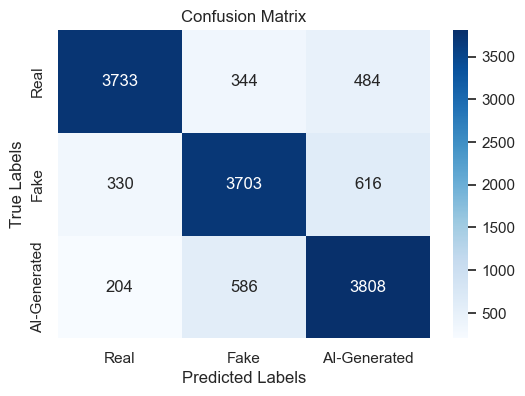

In [135]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [136]:
merged_df.tail(5)

,text,label,tokenized_text,doc_embedding
69219,dan patrick called increasing gas tax state sa...,real,"[dan, patrick, called, increasing, gas, tax, s...","[0.7560476, 0.61639655, 0.12591428, -1.1360931..."
69220,reuters national football league said tuesday ...,real,"[reuters, national, football, league, said, tu...","[0.22323744, 0.05393938, 0.083208114, -0.33228..."
69221,fort lauderdale fla drama come big trade baseb...,AI-generated,"[fort, lauderdale, fla, drama, come, big, trad...","[0.40184996, 0.16542271, 0.13334592, -0.156579..."
69222,mexico city reuters former mexico finance mini...,real,"[mexico, city, reuters, former, mexico, financ...","[-0.48408955, 0.0812739, -0.37240288, -0.39528..."
69223,beirut reuters syria army ally encircled islam...,real,"[beirut, reuters, syria, army, ally, encircled...","[-1.2717723, -0.9901217, -0.13536647, -0.85579..."


## Optuna Hyperparameter Tuning

In [158]:
# import optuna
# from transformers import TrainingArguments, Trainer
# from sklearn.metrics import accuracy_score

# # Define a function to compute metrics
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return {"accuracy": accuracy_score(labels, predictions)}

In [159]:
# # Define the objective function for Optuna
# def objective(trial):
#     # Define hyperparameters to tune
#     learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
#     per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
#     num_train_epochs = trial.suggest_int("num_train_epochs", 2, 5)
#     weight_decay = trial.suggest_float("weight_decay", 0.01, 0.1)

#     # Define training arguments
#     training_args = TrainingArguments(
#         output_dir="./results",
#         eval_strategy="epoch",
#         learning_rate=learning_rate,
#         per_device_train_batch_size=per_device_train_batch_size,
#         per_device_eval_batch_size=16,
#         num_train_epochs=num_train_epochs,
#         weight_decay=weight_decay,
#         logging_dir="./logs",
#         save_strategy="no",  # Disable saving checkpoints to save disk space
#         report_to="none",  # Disable logging to external services
#         load_best_model_at_end=False,  # Disable loading the best model at the end
#     )

#     # Initialize Trainer
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=test_dataset,
#         compute_metrics=compute_metrics,  # Add the compute_metrics function
#     )

#     # Train the model
#     trainer.train()
    
#     # Evaluate the model
#     eval_results = trainer.evaluate()

#     # Extract the accuracy metric
#     accuracy = eval_results.get("eval_accuracy")
#     if accuracy is None:
#         raise ValueError("Evaluation did not return an accuracy metric.")

#     return accuracy

In [160]:
# Initialize Optuna study
# study = optuna.create_study(direction="maximize")

[I 2025-02-05 16:38:27,268] A new study created in memory with name: no-name-28e39782-9955-4452-8b0e-b0e2ad521c8b


In [161]:
# # Start optimization
# study.optimize(objective, n_trials=10)

Epoch,Training Loss,Validation Loss


[W 2025-02-05 16:39:08,696] Trial 0 failed with parameters: {'learning_rate': 1.0157916125502907e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 3, 'weight_decay': 0.059038757887866916} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/w5/1ych38yj6yj23h6z6t94wlz40000gn/T/ipykernel_1934/979332002.py", line 34, in objective
    trainer.train()
  File "/opt/anaconda3/lib/python3.12/site-packages/transformers/trainer.py", line 2171, in train
    return inner_training_loop(
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/transformers/trainer.py", line 2536, in _inner_training_loop
    and (torch.isnan(tr_loss_step) or torch.isinf(tr_loss_step))
                                      ^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardIn

KeyboardInterrupt: 

In [ ]:
# # Print the best hyperparameters
# print("Best hyperparameters:", study.best_params)

In [ ]:
# # Print best accuracy
# print("Best accuracy:", study.best_value)

## RNNs Trial

Next we will test RNNs and see if they perform better than DistilBERT.

In [162]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Embedding, LSTM, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam

In [164]:
# encode the labels to integers
label_encoder = LabelEncoder()
merged_df['label_encoded'] = label_encoder.fit_transform(merged_df['label'])  # Convert labels to integers
num_classes = len(label_encoder.classes_)  # Number of unique labels

In [166]:
# prepare train and test splits
X = merged_df['text']
y = to_categorical(merged_df['label_encoded'], num_classes=num_classes)  # One-hot encode the labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [168]:
# Tokenize and pad sequences
max_words = 5000  # Vocabulary size
max_len = 150  # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

In [169]:
# define the RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, BatchNormalization, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam

vocab_size = 10000
embedding_dim = 128

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

rnn_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [170]:
# Compile the model
rnn_model.summary()
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Multiclass loss function
    metrics=['accuracy']
)
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [171]:
# Train the model
history = rnn_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 395s 228ms/step - accuracy: 0.7153 - loss: 0.6619 - val_accuracy: 0.8297 - val_loss: 0.3775
Epoch 2/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 403s 234ms/step - accuracy: 0.8354 - loss: 0.3834 - val_accuracy: 0.8237 - val_loss: 0.3796
Epoch 3/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 409s 237ms/step - accuracy: 0.8520 - loss: 0.3273 - val_accuracy: 0.8655 - val_loss: 0.2837
Epoch 4/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 428s 248ms/step - accuracy: 0.8721 - loss: 0.2725 - val_accuracy: 0.8670 - val_loss: 0.2805
Epoch 5/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 453s 262ms/step - accuracy: 0.8870 - loss: 0.2429 - val_accuracy: 0.8721 - val_loss: 0.2757
Epoch 6/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 438s 254ms/step - accuracy: 0.8986 - loss: 0.2213 - val_accuracy: 0.8706 - val_loss: 0.2853
Epoch 7/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 442s 256ms/step - accuracy: 0.9040 - loss: 0.2052 - val_accuracy: 0.8682 - val_loss: 0.2911
Epoch 8/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 455s 264ms/step - ac

In [174]:
test_loss, test_accuracy = rnn_model.evaluate(X_test_padded, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

432/432 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.8778 - loss: 0.3150
Test Loss: 0.3219
Test Accuracy: 0.8758


In [176]:
# Save the model for future use
rnn_model.save("rnn_model.keras")

432/432 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step


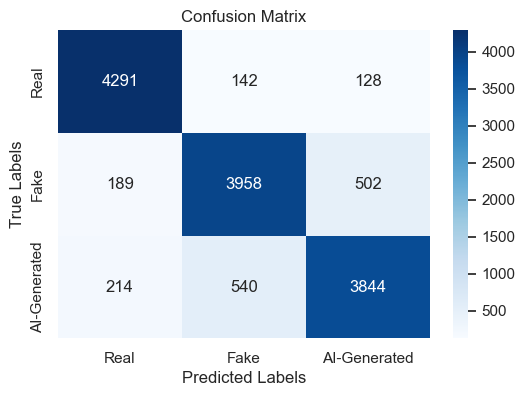

In [211]:
# Get predictions in probability form
y_pred_probs = rnn_model.predict(X_test_padded)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs with Word2Vec

In [217]:
# Pad sequences with Word2Vec embeddings
def get_sequence_embedding(tokens, model, vector_size, max_seq_len):
    sequence = []
    for word in tokens[:max_seq_len]:  # Truncate to max sequence length
        if word in model.wv:
            sequence.append(model.wv[word])
        else:
            sequence.append(np.zeros(vector_size))  # Handle OOV words
    # Pad sequence if it's shorter than max_seq_len
    while len(sequence) < max_seq_len:
        sequence.append(np.zeros(vector_size))
    return np.array(sequence)

In [219]:
# Retokenizing the text into lists of words
merged_df['tokenized_text'] = merged_df['text'].apply(lambda x: x.split())

In [221]:
# Extract tokenized sentences as a list of lists
tokenized_data = merged_df['tokenized_text'].tolist()

In [223]:
# Define maximum sequence length for LSTM and vector size
max_seq_len = 150
vector_size = 100

# Compute sequence embeddings for each document
merged_df['sequence_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: get_sequence_embedding(x, word2vec_model, vector_size, max_seq_len)
)

In [224]:
# Stack the sequences correctly for LSTM input
X = np.array(list(merged_df['sequence_embedding'].values))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [225]:
print(f"Training set shape for LSTM: {X_train.shape}")

Training set shape for LSTM: (55232, 150, 100)


In [226]:
print(f"Expected shape: (samples, timesteps, features) -> {X_train.shape[0], max_seq_len, vector_size}")

Expected shape: (samples, timesteps, features) -> (55232, 150, 100)


In [227]:
# Load the Word2Vec embeddings
embedding_matrix = np.zeros((len(word2vec_model.wv), vector_size))
word_index = {word: idx for idx, word in enumerate(word2vec_model.wv.index_to_key)}

for word, idx in word_index.items():
    embedding_matrix[idx] = word2vec_model.wv[word]

In [228]:
# Build the RNN model
word2vec_lstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, input_shape=(max_seq_len, vector_size))),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [229]:
# Compile the model
word2vec_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [231]:
print(word2vec_lstm_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [232]:
# train the model
history = word2vec_lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 321s 185ms/step - accuracy: 0.6744 - loss: 0.7702 - val_accuracy: 0.8591 - val_loss: 0.3241
Epoch 2/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 347s 201ms/step - accuracy: 0.8497 - loss: 0.3442 - val_accuracy: 0.8801 - val_loss: 0.2745
Epoch 3/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 353s 204ms/step - accuracy: 0.8712 - loss: 0.2859 - val_accuracy: 0.8848 - val_loss: 0.2502
Epoch 4/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 355s 206ms/step - accuracy: 0.8849 - loss: 0.2519 - val_accuracy: 0.8889 - val_loss: 0.2403
Epoch 5/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 364s 211ms/step - accuracy: 0.8914 - loss: 0.2329 - val_accuracy: 0.8949 - val_loss: 0.2305
Epoch 6/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 345s 200ms/step - accuracy: 0.8978 - loss: 0.2204 - val_accuracy: 0.8972 - val_loss: 0.2248
Epoch 7/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 338s 196ms/step - accuracy: 0.9009 - loss: 0.2089 - val_accuracy: 0.8977 - val_loss: 0.2271
Epoch 8/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 350s 203ms/step - ac

In [233]:
test_loss, test_accuracy = word2vec_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

432/432 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.8921 - loss: 0.2447
Test Loss: 0.2526
Test Accuracy: 0.8918


In [264]:
print(X_test_padded.shape)  # Should output (num_samples, max_sequence_length)

(13808, 150)


432/432 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step


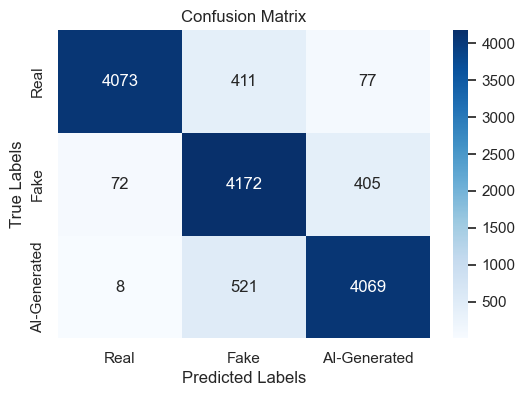

In [268]:
# Get predictions in probability form
y_pred_probs = word2vec_lstm_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the model for future use
rnn_model.save("lstm_model.keras")

## RNNs with GloVe Embeddings.
The dataset is already tokenized and preprocessed. Now, we need to:
- Load pre-trained GloVe embeddings.
- Create an embedding matrix for the vocabulary.
- Convert the tokenized text into sequences of GloVe embeddings.

In [270]:
import torch

# Load GloVe embeddings
def load_glove_embeddings(glove_path, embedding_dim=100):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_path = "GloVe_embeddings/glove.6B.100d.txt"  # Path to GloVe file
glove_embeddings = load_glove_embeddings(glove_path)

In [285]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(merged_df['text'])

# Convert the text to sequences of integers
X = tokenizer.texts_to_sequences(merged_df['text'])
max_seq_len = 150  # Maximum sequence length for padding

# Pad the sequences to ensure equal length
X = pad_sequences(X, maxlen=max_seq_len)

# One-hot encode the labels
y = pd.get_dummies(merged_df['label']).values

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [287]:
# Get the vocabulary size from the tokenizer
tokenizer_vocab_size = len(tokenizer.word_index) + 1  # Including padding token

# Set the embedding dimension (100 for GloVe 100d embeddings)
embedding_dim = 100

# Initialize the embedding matrix with zeros
embedding_matrix = np.zeros((tokenizer_vocab_size, embedding_dim))

# Map GloVe embeddings to the tokenizer's word index
for word, i in tokenizer.word_index.items():
    if i >= tokenizer_vocab_size:  # Skip words outside of the tokenizer's vocab
        break
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [289]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (55232, 150)
X_test shape: (13808, 150)
y_train shape: (55232, 3)
y_test shape: (13808, 3)


In [291]:
# Build the RNN model using Bidirectional LSTM with GloVe embeddings
glove_lstm_model = Sequential([
    # Use the pretrained GloVe embeddings with non-trainable weights
    Embedding(input_dim=tokenizer_vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),  # Use non-trainable GloVe embeddings
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

In [293]:
# Compile the model
glove_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

In [295]:
# Model summary
glove_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │    25,721,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,721,700 (98.12 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 25,721,700 (98.12 MB)

In [297]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (55232, 150)
X_test shape: (13808, 150)
y_train shape: (55232, 3)
y_test shape: (13808, 3)


In [299]:
# Train the model
glove_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 337s 194ms/step - accuracy: 0.5988 - loss: 0.9790 - val_accuracy: 0.7768 - val_loss: 0.4932
Epoch 2/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 367s 213ms/step - accuracy: 0.7707 - loss: 0.5338 - val_accuracy: 0.8113 - val_loss: 0.4192
Epoch 3/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 370s 214ms/step - accuracy: 0.7962 - loss: 0.4574 - val_accuracy: 0.8134 - val_loss: 0.4191
Epoch 4/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 371s 215ms/step - accuracy: 0.8187 - loss: 0.4096 - val_accuracy: 0.8365 - val_loss: 0.3531
Epoch 5/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 344s 199ms/step - accuracy: 0.8347 - loss: 0.3723 - val_accuracy: 0.8467 - val_loss: 0.3441
Epoch 6/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 354s 205ms/step - accuracy: 0.8436 - loss: 0.3497 - val_accuracy: 0.8558 - val_loss: 0.3243
Epoch 7/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 374s 216ms/step - accuracy: 0.8495 - loss: 0.3341 - val_accuracy: 0.8631 - val_loss: 0.3079
Epoch 8/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 374s 217ms/step - ac

In [302]:
test_loss, test_accuracy = glove_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

432/432 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.8742 - loss: 0.2861
Test Loss: 0.2888
Test Accuracy: 0.8738


432/432 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step


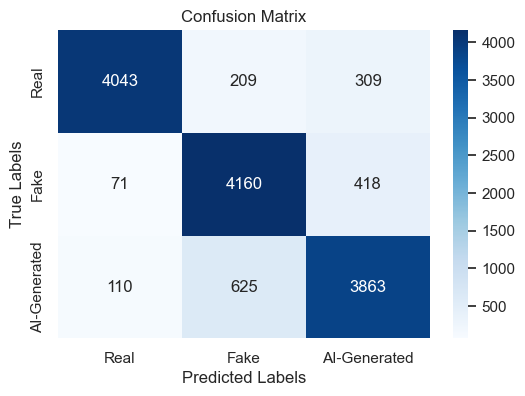

In [303]:
# Get predictions in probability form
y_pred_probs = glove_lstm_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs LSTM with FastText

In [304]:
pip install fasttext

Note: you may need to restart the kernel to use updated packages.


In [305]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [306]:
merged_df.head(5)

,text,label,label_encoded,tokenized_text,sequence_embedding
0,berlin reuters turkey summoned germany ambassa...,real,2,"[berlin, reuters, turkey, summoned, germany, a...","[[-1.0136616230010986, 0.5112946033477783, 0.3..."
1,florida woman charged killing husband shot wou...,AI-generated,0,"[florida, woman, charged, killing, husband, sh...","[[1.2754135131835938, -0.09516165405511856, -0..."
2,final day afghanistan president obama haunted ...,AI-generated,0,"[final, day, afghanistan, president, obama, ha...","[[0.5972871780395508, 0.6896737217903137, 1.56..."
3,group grifter clinton scammer chelsea demand h...,fake,1,"[group, grifter, clinton, scammer, chelsea, de...","[[-1.3703821897506714, -3.4398229122161865, -0..."
4,republican front runner donald trump recently ...,fake,1,"[republican, front, runner, donald, trump, rec...","[[1.7499380111694336, -0.3571295440196991, -3...."


In [334]:
import gensim
import numpy as np

# Load FastText vectors using gensim
fasttext_model_path = 'wiki-news-300d-1M-subword.vec'  # Path to the unzipped .vec file
fasttext_model = gensim.models.KeyedVectors.load_word2vec_format(fasttext_model_path, binary=False)

In [336]:
embedding_dim = 300  # FastText vectors are 300-dimensional

# Create an embedding matrix
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, embedding_dim))

for word, i in tokenizer.word_index.items():
    try:
        # Get FastText vector for the word
        embedding_vector = fasttext_model[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        # If the word is not in the FastText vocabulary, leave as zeros
        embedding_matrix[i] = np.zeros(embedding_dim)

In [338]:
# Build the model
fasttext_lstm_model = Sequential([
    # Use the pretrained FastText embeddings with non-trainable weights
    Embedding(input_dim=len(tokenizer.word_index) + 1,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),  # Don't train the FastText embeddings
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

# Compile the model
fasttext_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
fasttext_lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │    77,165,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,165,100 (294.36 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 77,165,100 (294.36 MB)

In [342]:
history = fasttext_lstm_model.fit(X_train, y_train, 
                    epochs=10,  
                    batch_size=32,
                    validation_data=(X_test, y_test))

Epoch 1/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 405s 234ms/step - accuracy: 0.6334 - loss: 0.8542 - val_accuracy: 0.8041 - val_loss: 0.4546
Epoch 2/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 424s 246ms/step - accuracy: 0.7904 - loss: 0.4860 - val_accuracy: 0.8226 - val_loss: 0.3881
Epoch 3/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 424s 246ms/step - accuracy: 0.8125 - loss: 0.4269 - val_accuracy: 0.8332 - val_loss: 0.3788
Epoch 4/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 430s 249ms/step - accuracy: 0.8225 - loss: 0.4021 - val_accuracy: 0.8373 - val_loss: 0.3638
Epoch 5/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 420s 243ms/step - accuracy: 0.8315 - loss: 0.3778 - val_accuracy: 0.8274 - val_loss: 0.3820
Epoch 6/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 430s 249ms/step - accuracy: 0.8390 - loss: 0.3641 - val_accuracy: 0.8518 - val_loss: 0.3286
Epoch 7/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 434s 251ms/step - accuracy: 0.8459 - loss: 0.3442 - val_accuracy: 0.8247 - val_loss: 0.3847
Epoch 8/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 409s 237ms/step - ac

In [343]:
test_loss, test_accuracy = fasttext_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

432/432 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.8523 - loss: 0.3349
Test Loss: 0.3317
Test Accuracy: 0.8536


432/432 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step


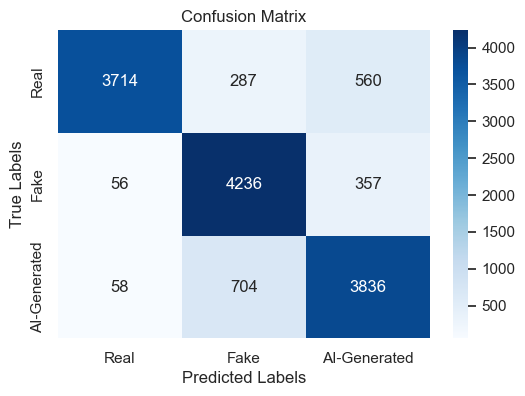

In [344]:
# Get predictions in probability form
y_pred_probs = fasttext_lstm_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs with CNNs layers.
Combining CNN and RNN layers is a powerful approach for text classification tasks, where CNNs capture local patterns, and RNNs handle sequential dependencies. 
Since Word2Vec was the best performing embedding with LSTM we will use here as well:

In [366]:
# Load and pad the Word2Vec embedding vectors
def get_sequence_embedding(tokens, model, vector_size, max_seq_len):
    sequence = []
    for word in tokens[:max_seq_len]:  # Truncate to max sequence length
        if word in model.wv:
            sequence.append(model.wv[word])
        else:
            sequence.append(np.zeros(vector_size))  # Handle OOV words
    # Pad sequence if it's shorter than max_seq_len
    while len(sequence) < max_seq_len:
        sequence.append(np.zeros(vector_size))
    return np.array(sequence)

# Compute sequence embeddings for each document
merged_df['sequence_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: get_sequence_embedding(x, word2vec_model, vector_size, max_seq_len)
)

# Stack the sequences correctly for model input
X = np.array(list(merged_df['sequence_embedding'].values))
print(f"Input shape: {X.shape}")  # Ensure shape is (num_samples, max_seq_len, vector_size)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Input shape: (69040, 150, 100)


In [368]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Input

# Build the CNN + BiLSTM model
cnn_rnn_model = Sequential([
    Input(shape=(max_seq_len, vector_size)),  # Explicit input layer
    # CNN layers
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    Dropout(0.5),

    # RNN layers
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.5),

    # Fully connected layers
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # Three output classes: Real, Fake, AI-generated
])

In [370]:
# Compile the model
cnn_rnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

In [372]:
# Model summary
cnn_rnn_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 148, 128)       │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 74, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,819 (573.51 KB)

 Trainable params: 146,307 (571.51 KB)

 Non-trainable params: 512 (2.00 KB)

In [374]:
# Train the model
history = cnn_rnn_model.fit(X_train, 
                            y_train, 
                            epochs=10, 
                            batch_size=32, 
                            validation_data=(X_test, y_test))

Epoch 1/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.5186 - loss: 1.2769 - val_accuracy: 0.8270 - val_loss: 0.3822
Epoch 2/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.7690 - loss: 0.5613 - val_accuracy: 0.8502 - val_loss: 0.3500
Epoch 3/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.8150 - loss: 0.4325 - val_accuracy: 0.8618 - val_loss: 0.3192
Epoch 4/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.8411 - loss: 0.3689 - val_accuracy: 0.8645 - val_loss: 0.2994
Epoch 5/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.8519 - loss: 0.3330 - val_accuracy: 0.8691 - val_loss: 0.2852
Epoch 6/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 55s 32ms/step - accuracy: 0.8606 - loss: 0.3114 - val_accuracy: 0.8751 - val_loss: 0.2778
Epoch 7/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.8650 - loss: 0.2974 - val_accuracy: 0.8778 - val_loss: 0.2668
Epoch 8/10
1726/1726 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.8665 -

In [378]:
test_loss, test_accuracy = cnn_rnn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8745 - loss: 0.2639
Test Loss: 0.2698
Test Accuracy: 0.8728


432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


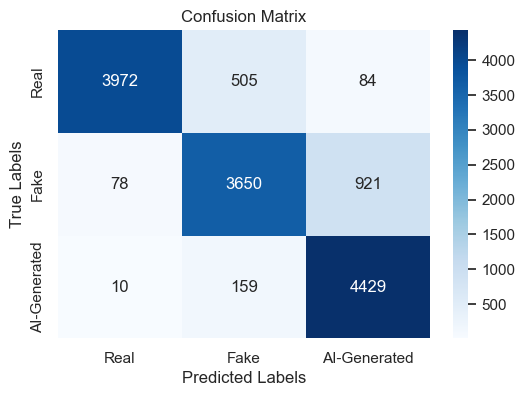

In [380]:
# Get predictions in probability form
y_pred_probs = cnn_rnn_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [382]:
# Train the model
history = cnn_rnn_model.fit(X_train, 
                            y_train, 
                            epochs=20, 
                            batch_size=64, 
                            validation_data=(X_test, y_test))

Epoch 1/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 47s 53ms/step - accuracy: 0.8845 - loss: 0.2414 - val_accuracy: 0.8759 - val_loss: 0.2645
Epoch 2/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.8868 - loss: 0.2367 - val_accuracy: 0.8777 - val_loss: 0.2823
Epoch 3/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.8881 - loss: 0.2356 - val_accuracy: 0.8819 - val_loss: 0.2597
Epoch 4/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.8904 - loss: 0.2278 - val_accuracy: 0.8802 - val_loss: 0.2659
Epoch 5/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.8892 - loss: 0.2273 - val_accuracy: 0.8812 - val_loss: 0.2712
Epoch 6/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 50s 57ms/step - accuracy: 0.8949 - loss: 0.2199 - val_accuracy: 0.8749 - val_loss: 0.2684
Epoch 7/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 0.8954 - loss: 0.2159 - val_accuracy: 0.8821 - val_loss: 0.2654
Epoch 8/20
863/863 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - accuracy: 0.8953 - loss: 0.2137 - 

In [383]:
test_loss, test_accuracy = cnn_rnn_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8825 - loss: 0.2777
Test Loss: 0.2885
Test Accuracy: 0.8826


432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


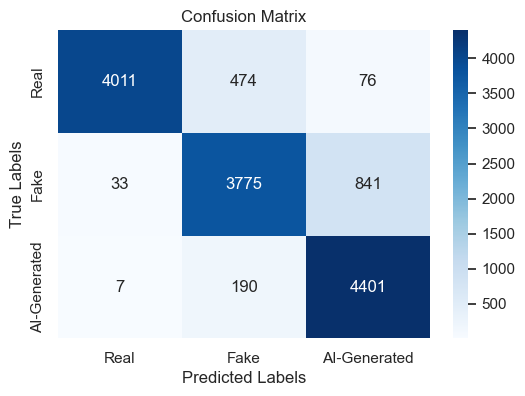

In [384]:
# Get predictions in probability form
y_pred_probs = cnn_rnn_model.predict(X_test)

# Convert to class indices (the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert the true labels if they are one-hot encoded
y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting
labels = ['Real', 'Fake', 'AI-Generated']
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RoBERTa Trial
Decided to investigate a stronger model than DistilBERT to see if we can achieve even higher results.

In [397]:
merged_df.head()

,text,label,label_encoded,tokenized_text,sequence_embedding
0,berlin reuters turkey summoned germany ambassa...,real,2,"[berlin, reuters, turkey, summoned, germany, a...","[[-1.0136616230010986, 0.5112946033477783, 0.3..."
1,florida woman charged killing husband shot wou...,AI-generated,0,"[florida, woman, charged, killing, husband, sh...","[[1.2754135131835938, -0.09516165405511856, -0..."
2,final day afghanistan president obama haunted ...,AI-generated,0,"[final, day, afghanistan, president, obama, ha...","[[0.5972871780395508, 0.6896737217903137, 1.56..."
3,group grifter clinton scammer chelsea demand h...,fake,1,"[group, grifter, clinton, scammer, chelsea, de...","[[-1.3703821897506714, -3.4398229122161865, -0..."
4,republican front runner donald trump recently ...,fake,1,"[republican, front, runner, donald, trump, rec...","[[1.7499380111694336, -0.3571295440196991, -3...."


In [399]:
merged_df.drop(['tokenized_text'], axis=1, inplace=True)

In [401]:
merged_df.drop(['label_encoded'], axis=1, inplace=True)

In [403]:
merged_df.drop(['sequence_embedding'], axis=1, inplace=True)

In [405]:
merged_df.head()

,text,label
0,berlin reuters turkey summoned germany ambassa...,real
1,florida woman charged killing husband shot wou...,AI-generated
2,final day afghanistan president obama haunted ...,AI-generated
3,group grifter clinton scammer chelsea demand h...,fake
4,republican front runner donald trump recently ...,fake


In [390]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Load RoBERTa tokenizer and model
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [407]:
# Convert DataFrame to Hugging Face Dataset
dataset = Dataset.from_pandas(merged_df)

# Split into train and test sets
dataset = dataset.train_test_split(test_size=0.2)
train_dataset = dataset["train"]
test_dataset = dataset["test"]

In [409]:
# Tokenize function
def tokenize_function(example):
    return roberta_tokenizer(example["text"], padding="max_length", truncation=True, max_length=512)

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/55232 [00:00<?, ? examples/s]

Map:   0%|          | 0/13808 [00:00<?, ? examples/s]

In [410]:
# Remove unused columns
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

# Set format for PyTorch
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [413]:
# Map labels to numeric values
label_map = {"fake": 0, "real": 1, "AI-generated": 2}

train_dataset = train_dataset.map(lambda x: {"label": label_map[x["label"]]})
test_dataset = test_dataset.map(lambda x: {"label": label_map[x["label"]]})

Map:   0%|          | 0/55232 [00:00<?, ? examples/s]

Map:   0%|          | 0/13808 [00:00<?, ? examples/s]

In [418]:
# Define training arguments
roberta_training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Evaluate at the end of every epoch
    save_strategy="epoch",        # Save the best model at the end of every epoch
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    save_total_limit=2,
    load_best_model_at_end=True,
)

# Initialize Trainer
roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [420]:
# Train the model
roberta_trainer.train()

Epoch,Training Loss,Validation Loss
1,0.179600,0.159753
2,0.143500,0.158390
3,0.120800,0.167846


TrainOutput(global_step=10356, training_loss=0.16117662073977437, metrics={'train_runtime': 15885.1743, 'train_samples_per_second': 10.431, 'train_steps_per_second': 0.652, 'total_flos': 4.359684086385869e+16, 'train_loss': 0.16117662073977437, 'epoch': 3.0})

In [422]:
# Evaluate the model
roberta_trainer.evaluate()

{'eval_loss': 0.15839047729969025,
 'eval_runtime': 389.762,
 'eval_samples_per_second': 35.427,
 'eval_steps_per_second': 2.214,
 'epoch': 3.0}

In [423]:
# Save the model and tokenizer
roberta_model.save_pretrained("./roberta-finetuned")
roberta_tokenizer.save_pretrained("./roberta-finetuned")

('./roberta-finetuned/tokenizer_config.json',
 './roberta-finetuned/special_tokens_map.json',
 './roberta-finetuned/vocab.json',
 './roberta-finetuned/merges.txt',
 './roberta-finetuned/added_tokens.json')

In [424]:
# Get predictions and true labels
roberta_predictions = trainer.predict(test_dataset)
roberta_pred_labels = predictions.predictions.argmax(axis=-1)
roberta_true_labels = test_dataset["label"]

In [425]:
print("Accuracy:", accuracy_score(roberta_true_labels, roberta_pred_labels))

Accuracy: 0.9268539976825029


In [426]:
print("Classification Report:\n", classification_report(roberta_true_labels, roberta_pred_labels, target_names=["Fake", "Real", "AI-generated"]))

Classification Report:
               precision    recall  f1-score   support

        Fake       0.88      0.92      0.90      4626
        Real       0.92      0.87      0.89      4578
AI-generated       0.98      0.99      0.99      4604

    accuracy                           0.93     13808
   macro avg       0.93      0.93      0.93     13808
weighted avg       0.93      0.93      0.93     13808



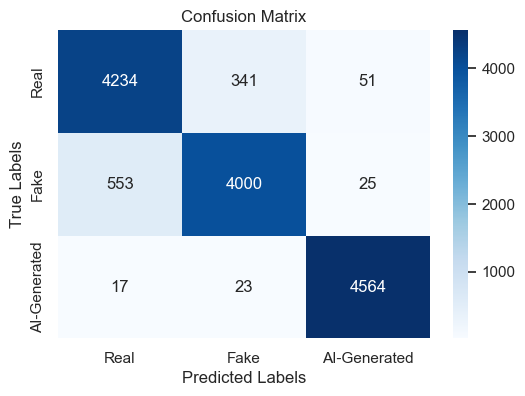

In [432]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(roberta_true_labels, roberta_pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## DistilBERT Re-Implementation
downgrading to DistilBERT to compare with RoBERTa

In [553]:
merged_df.head()

,text,label
0,berlin reuters turkey summoned germany ambassa...,real
1,florida woman charged killing husband shot wou...,AI-generated
2,final day afghanistan president obama haunted ...,AI-generated
3,group grifter clinton scammer chelsea demand h...,fake
4,republican front runner donald trump recently ...,fake


In [555]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# Load tokenizer and model
distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [557]:
from datasets import Dataset

# Convert pandas DataFrame to a Hugging Face Dataset
dataset = Dataset.from_pandas(merged_df)

# Split the dataset into train and test sets
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset['train']
test_dataset = dataset['test']

In [559]:
def tokenize_function(example):
    return distilbert_tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove unused columns and set format for PyTorch
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/55232 [00:00<?, ? examples/s]

Map:   0%|          | 0/13808 [00:00<?, ? examples/s]

In [560]:
# Map the labels to numeric values
label_map = {'fake': 0, 'real': 1, 'AI-generated': 2}

train_dataset = train_dataset.map(lambda x: {'label': label_map[x['label']]})
test_dataset = test_dataset.map(lambda x: {'label': label_map[x['label']]})

Map:   0%|          | 0/55232 [00:00<?, ? examples/s]

Map:   0%|          | 0/13808 [00:00<?, ? examples/s]

In [561]:
from transformers import TrainingArguments, Trainer

# Define model
distilbert_training_args = TrainingArguments(
    output_dir="./distil_results",
    eval_strategy="epoch",  # Evaluate at the end of every epoch
    save_strategy="epoch",        # Save the best model at the end of every epoch
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.1,
    logging_dir="./distil_logs",
    load_best_model_at_end=True,
)

In [562]:
from transformers import EarlyStoppingCallback
from transformers import get_scheduler
from torch.optim import AdamW

# Define the optimizer
optimizer = AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=0.1)

# Total training steps
num_training_steps = len(train_dataset) // distilbert_training_args.per_device_train_batch_size * distilbert_training_args.num_train_epochs


# Define a linear learning rate scheduler
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

In [563]:
# Initialize trainer
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    optimizers=(optimizer, lr_scheduler)
)

# Train the model
distilbert_trainer.train()

Epoch,Training Loss,Validation Loss
1,0.176800,0.154004
2,0.129600,0.142378
3,0.101700,0.157832
4,0.074800,0.240578


TrainOutput(global_step=6904, training_loss=0.15351218807048067, metrics={'train_runtime': 10517.5386, 'train_samples_per_second': 26.257, 'train_steps_per_second': 0.821, 'total_flos': 2.926627936351027e+16, 'train_loss': 0.15351218807048067, 'epoch': 4.0})

In [564]:
# Evaluate the model
distilbert_trainer.evaluate()

{'eval_loss': 0.14237773418426514,
 'eval_runtime': 219.4192,
 'eval_samples_per_second': 62.93,
 'eval_steps_per_second': 1.969,
 'epoch': 4.0}

In [565]:
# Save model for later use
distilbert_model.save_pretrained("./distilbert-finetuned")
distilbert_tokenizer.save_pretrained("./distilbert-finetuned")

('./distilbert-finetuned/tokenizer_config.json',
 './distilbert-finetuned/special_tokens_map.json',
 './distilbert-finetuned/vocab.txt',
 './distilbert-finetuned/added_tokens.json')

In [566]:
# Get predictions and true labels from the trainer
distilbert_predictions = trainer.predict(test_dataset)
distilbert_pred_labels = predictions.predictions.argmax(axis=-1)
distilbert_true_labels = test_dataset['label']

In [567]:
# Evaluate performance
print("Accuracy:", accuracy_score(distilbert_true_labels, distilbert_pred_labels))

Accuracy: 0.9268539976825029


In [568]:
print("Classification Report:\n", classification_report(distilbert_true_labels, distilbert_pred_labels))

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90      4626
           1       0.91      0.88      0.89      4578
           2       0.99      0.99      0.99      4604

    accuracy                           0.93     13808
   macro avg       0.93      0.93      0.93     13808
weighted avg       0.93      0.93      0.93     13808



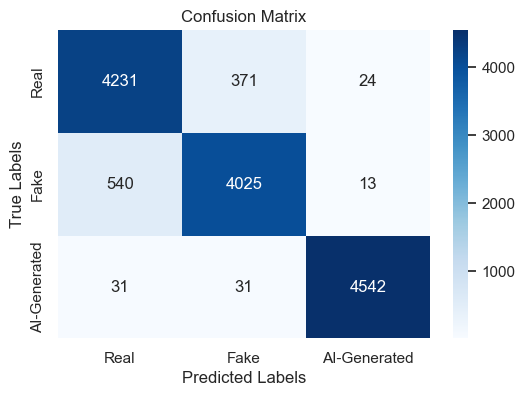

In [569]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(distilbert_true_labels, distilbert_pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

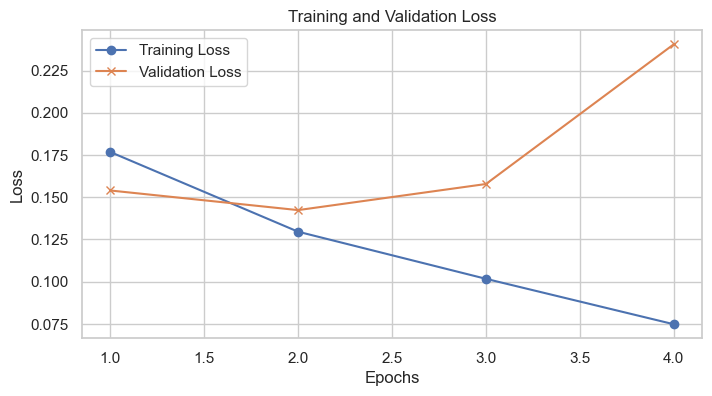

In [583]:
# Paste training & validation losses of each epoch
epochs = [1, 2, 3, 4]
train_losses = [0.176800, 0.129600, 0.101700, 0.074800]
val_losses = [0.154004, 0.142378, 0.157832, 0.240578]

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [589]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from scipy.special import softmax

# Extract logits from predictions
logits = distilbert_predictions.predictions

# Convert logits to probabilities using softmax
probabilities = softmax(logits, axis=-1)

In [591]:
from sklearn.preprocessing import label_binarize

# Assuming `distilbert_true_labels` contains integer class labels
num_classes = len(np.unique(distilbert_true_labels))
true_labels_one_hot = label_binarize(distilbert_true_labels, classes=np.arange(num_classes))

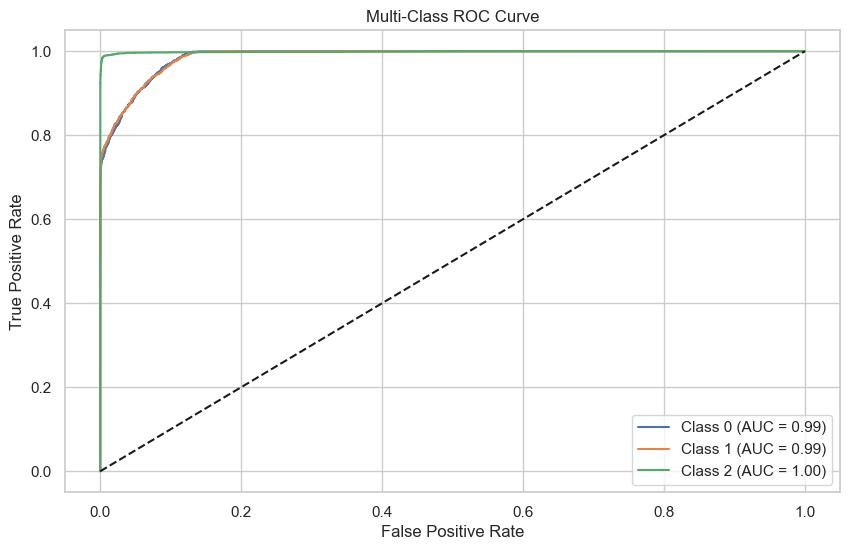

In [595]:
# Plot ROC for each class
plt.figure(figsize=(10, 6))
for i in range(num_classes):
    # Compute False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], probabilities[:, i])
    # Compute AUC for the current class
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve for the current class with its AUC value in the legend
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for random guessing
plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

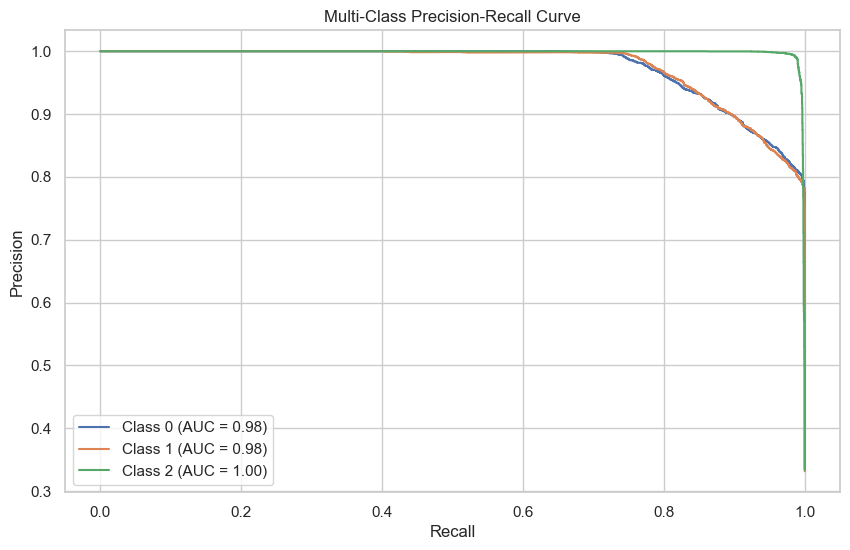

In [597]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Create a new figure for the precision-recall curves
plt.figure(figsize=(10, 6))

# Plot the precision-recall curve for each class
for i in range(num_classes):
    # Compute precision, recall, and thresholds for class i
    precision, recall, _ = precision_recall_curve(true_labels_one_hot[:, i], probabilities[:, i])
    
    # Compute AUC for the precision-recall curve
    pr_auc = auc(recall, precision)
    
    # Plot the precision-recall curve for the current class
    plt.plot(recall, precision, label=f"Class {i} (AUC = {pr_auc:.2f})")

# Add plot title and axis labels
plt.title("Multi-Class Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

# Display legend for class labels
plt.legend()

# Show the plot
plt.show()
